In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("C:/Users/waghm/OneDrive/Documents/Project/DMart_Sales_Data.xlsx")

In [3]:
df.shape

(5000, 10)

In [4]:
df.head(10)

,Order_ID,Order_Date,Store_ID,City,Category,Product_Name,Quantity,Sales,Discount,Profit
0,1,2024-07-21,S10,Mumbai,Electronics,Headphones,15,38670,172,10703
1,2,2024-02-20,S07,Aurangabad,Clothing,Jacket,5,3220,116,764
2,3,2024-08-31,S04,Aurangabad,Grocery,Rice,7,12831,202,1570
3,4,2024-10-05,S10,Pune,Electronics,Mobile,19,10298,129,1746
4,5,2024-01-07,S03,Pune,Electronics,Mixer,7,10927,267,3033
5,6,2024-11-14,S10,Pune,Grocery,Sugar,15,23715,219,5413
6,7,2024-01-31,S06,Mumbai,Electronics,Mixer,12,18084,199,2832
7,8,2024-01-28,S04,Aurangabad,Electronics,Laptop,15,4080,228,527
8,9,2024-03-27,S05,Pune,Grocery,Sugar,11,11253,33,2676
9,10,2024-05-26,S09,Nagpur,Clothing,Jeans,9,15741,128,3571


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order_ID      5000 non-null   int64 
 1   Order_Date    5000 non-null   object
 2   Store_ID      5000 non-null   object
 3   City          5000 non-null   object
 4   Category      5000 non-null   object
 5   Product_Name  5000 non-null   object
 6   Quantity      5000 non-null   int64 
 7   Sales         5000 non-null   int64 
 8   Discount      5000 non-null   int64 
 9   Profit        5000 non-null   int64 
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


In [6]:
df.describe()

,Order_ID,Quantity,Sales,Discount,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,10.475600,16170.647800,149.899000,3207.082400
std,1443.520003,5.770101,13149.811782,87.173284,2854.611677
min,1.000000,1.000000,105.000000,0.000000,23.000000
25%,1250.750000,5.000000,5315.000000,74.000000,981.750000
50%,2500.500000,10.000000,12709.500000,150.000000,2364.500000
75%,3750.250000,15.000000,24026.000000,226.000000,4640.750000
max,5000.000000,20.000000,59840.000000,300.000000,16626.000000


In [7]:
df.isnull().sum()

Order_ID        0
Order_Date      0
Store_ID        0
City            0
Category        0
Product_Name    0
Quantity        0
Sales           0
Discount        0
Profit          0
dtype: int64

### Data Cleaning

In [8]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_ID      5000 non-null   int64         
 1   Order_Date    5000 non-null   datetime64[ns]
 2   Store_ID      5000 non-null   object        
 3   City          5000 non-null   object        
 4   Category      5000 non-null   object        
 5   Product_Name  5000 non-null   object        
 6   Quantity      5000 non-null   int64         
 7   Sales         5000 non-null   int64         
 8   Discount      5000 non-null   int64         
 9   Profit        5000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage: 390.8+ KB


In [10]:
df = df.drop_duplicates()

In [11]:
df.head(10)

,Order_ID,Order_Date,Store_ID,City,Category,Product_Name,Quantity,Sales,Discount,Profit
0,1,2024-07-21,S10,Mumbai,Electronics,Headphones,15,38670,172,10703
1,2,2024-02-20,S07,Aurangabad,Clothing,Jacket,5,3220,116,764
2,3,2024-08-31,S04,Aurangabad,Grocery,Rice,7,12831,202,1570
3,4,2024-10-05,S10,Pune,Electronics,Mobile,19,10298,129,1746
4,5,2024-01-07,S03,Pune,Electronics,Mixer,7,10927,267,3033
5,6,2024-11-14,S10,Pune,Grocery,Sugar,15,23715,219,5413
6,7,2024-01-31,S06,Mumbai,Electronics,Mixer,12,18084,199,2832
7,8,2024-01-28,S04,Aurangabad,Electronics,Laptop,15,4080,228,527
8,9,2024-03-27,S05,Pune,Grocery,Sugar,11,11253,33,2676
9,10,2024-05-26,S09,Nagpur,Clothing,Jeans,9,15741,128,3571


### key Metrics

In [12]:
# Total Sales
total_sales = df['Sales'].sum()
total_sales

np.int64(80853239)

In [13]:
# Total Profit
total_profit = df['Profit'].sum()
total_profit

np.int64(16035412)

In [14]:
# Total Orders
total_orders = df['Order_ID'].sum()
total_orders

np.int64(12502500)

In [15]:
# Total Average
total_avg = total_sales/total_orders
total_avg

np.float64(6.466965726854629)

In [16]:
# Highest Month sales
df['Month'] = df['Order_Date'].dt.month
monthly_sales = df.groupby('Month')['Sales'].sum()
monthly_sales

Month
1     7052592
2     5853597
3     6906628
4     6250371
5     6662146
6     6818710
7     7271502
8     6599837
9     6983298
10    7003611
11    6803344
12    6647603
Name: Sales, dtype: int64

In [17]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

Product_Name
Mobile        7341819
Headphones    7209549
Mixer         7015110
Kurta         6891973
T-Shirt       6534467
Laptop        6490185
Jeans         6453128
Jacket        5995138
Sugar         5558168
Oil           5503684
Name: Sales, dtype: int64

In [18]:
city_sales = df.groupby('City')['Sales'].sum()
city_sales

City
Aurangabad    16269507
Mumbai        15571200
Nagpur        16963358
Nashik        16256048
Pune          15793126
Name: Sales, dtype: int64

In [19]:
profit_category = df.groupby('Category')['Profit'].sum()
profit_category

Category
Clothing       5112341
Electronics    5567520
Grocery        5355551
Name: Profit, dtype: int64

In [20]:
# Analysis of Profit vs Discount using Scatter plot

<Axes: xlabel='Profit', ylabel='Discount'>

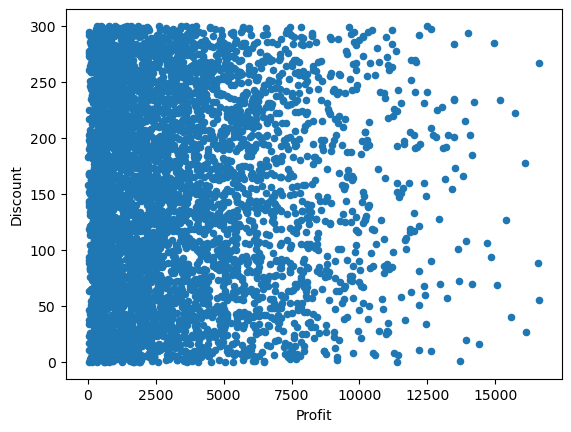

In [21]:
df.plot.scatter(x='Profit', y='Discount')

In [22]:
sales_store = df.groupby('Store_ID')['Sales'].sum()
sales_store

Store_ID
S01    7338177
S02    8067905
S03    8619004
S04    7309533
S05    8491071
S06    8032029
S07    8648577
S08    7693546
S09    7956056
S10    8697341
Name: Sales, dtype: int64

In [23]:
df.columns

Index(['Order_ID', 'Order_Date', 'Store_ID', 'City', 'Category',
       'Product_Name', 'Quantity', 'Sales', 'Discount', 'Profit', 'Month'],
      dtype='object')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_ID      5000 non-null   int64         
 1   Order_Date    5000 non-null   datetime64[ns]
 2   Store_ID      5000 non-null   object        
 3   City          5000 non-null   object        
 4   Category      5000 non-null   object        
 5   Product_Name  5000 non-null   object        
 6   Quantity      5000 non-null   int64         
 7   Sales         5000 non-null   int64         
 8   Discount      5000 non-null   int64         
 9   Profit        5000 non-null   int64         
 10  Month         5000 non-null   int32         
dtypes: datetime64[ns](1), int32(1), int64(5), object(4)
memory usage: 410.3+ KB


In [25]:
# 1. Make sure Order_Date is datetime
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

# 2. Extract date parts
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Day"] = df["Order_Date"].dt.day

# 3. DROP original datetime column
df.drop(columns=["Order_Date"], inplace=True)

# 4. Encode all text columns
df = pd.get_dummies(df, columns=["Store_ID", "City", "Category", "Product_Name"])

# 5. Split features and target
X = df[["Quantity", "Sales", "Discount"]]
y = df["Profit"]
# 6. Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7. Safety check
print(X_train.dtypes.unique())  # should show only int/float/bool

# 8. Train
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


[dtype('int64')]


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
from sklearn.metrics import r2_score, mean_absolute_error
y_pred = model.predict(X_test)

In [27]:
print("R2 Score: ", r2_score(y_test, y_pred))
print("mean_absolute_error: ", mean_absolute_error(y_test, y_pred))

R2 Score:  0.8318690817375096
mean_absolute_error:  789.2905475054292


In [28]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_rf_pred = rf.predict(X_test)

In [30]:
print("R2 Score: ", r2_score(y_test, y_pred))
print("mean_absolute_error: ", mean_absolute_error(y_test, y_rf_pred))

R2 Score:  0.8318690817375096
mean_absolute_error:  839.83793


In [31]:
import joblib
joblib.dump(rf, "dmart_sales.pkl")

['dmart_sales.pkl']